In [1]:
# Imports 
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.signal import resample
import sqlite3

In [28]:
# Constants

# MediaPipe joint indices (33 joints)
LEFT_HIP = 23
RIGHT_HIP = 24
LEFT_SHOULDER = 11
RIGHT_SHOULDER = 12
LEFT_KNEE = 25
RIGHT_KNEE = 26
LEFT_ANKLE = 27
RIGHT_ANKLE = 28

NUM_JOINTS = 33 # All Mediapipe landmarkers

GAIT_JOINTS = [
    2, 5,     # eyes (head orientation)
    11, 12,   # shoulders
    23, 24,   # hips
    25, 26,   # knees
    27, 28,   # ankles
    29, 30,   # heels
    31, 32    # foot index
]

#Target labels
LABEL_MAP = {
    "normal": 0,
    "abnormal": 1
}


In [3]:
# Load data from MediaPipe Pose stored in Parquet file

df = pl.read_parquet('/Users/pierre/Documents/NF_Bootcamp/Capstone/GAITy-Capstone-Modeling/data/filled_gait_data_encoded.parquet')


In [25]:
# 1. Data cleaning: Remove videos with high percentage of missing frames 

def missing_frames_summary_polars(df: pl.DataFrame, video_col="video_id", frame_col="frame"):
    """
    Compute number and % of missing frames per video.
    
    Returns:
        summary: dict with overall stats
        frame_stats: Polars DataFrame with per-video missing frames info
    """
    # Count unique frames per video
    unique_counts = (
        df.group_by(video_col)
          .agg(pl.col(frame_col).n_unique().alias("num_unique_frames"))
    )

    # Min/max frame per video
    frame_range = (
        df.group_by(video_col)
          .agg([
              pl.col(frame_col).min().alias("min_frame"),
              pl.col(frame_col).max().alias("max_frame")
          ])
    )

    # Join to compute missing frames
    frame_stats = unique_counts.join(frame_range, on=video_col)

    # Compute missing frames and percentage
    frame_stats = frame_stats.with_columns([
        (pl.col("max_frame") - pl.col("min_frame") + 1 - pl.col("num_unique_frames")).alias("num_missing_frames"),
        ((pl.col("max_frame") - pl.col("min_frame") + 1 - pl.col("num_unique_frames")) /
         (pl.col("max_frame") - pl.col("min_frame") + 1) * 100).alias("pct_missing")
    ])

    # Overall summary stats
    summary = {
        "mean_missing": frame_stats["num_missing_frames"].mean(),
        "std_missing": frame_stats["num_missing_frames"].std(),
        "max_missing": frame_stats["num_missing_frames"].max(),
        "mean_pct_missing": frame_stats["pct_missing"].mean()
    }

    # Order by descending number of missing frames
    frame_stats = frame_stats.sort("num_missing_frames", descending=True)

    return summary, frame_stats



def filter_videos_by_missing_frames(df: pl.DataFrame, video_col="video_id", frame_col="frame", threshold_pct=5.0):
    """
    Filter out videos where the percentage of missing frames exceeds threshold_pct.
    
    Args:
        df: Polars DataFrame with per-frame landmarks
        video_col: column identifying videos
        frame_col: column with frame numbers
        threshold_pct: maximum allowed percentage of missing frames (e.g., 5.0)
    
    Returns:
        filtered_df: DataFrame with videos below the missing frame threshold
        removed_videos: list of video_ids that were removed
    """
    
    # Compute missing frames per video
    _, frame_stats = missing_frames_summary_polars(df, video_col=video_col, frame_col=frame_col)
    
    # Find videos to keep
    videos_to_keep = frame_stats.filter(pl.col("pct_missing") <= threshold_pct)[video_col].to_list()
    
    # Filter original dataframe
    filtered_df = df.filter(pl.col(video_col).is_in(videos_to_keep))
    
    # List of removed videos for logging
    removed_videos = frame_stats.filter(pl.col("pct_missing") > threshold_pct)[video_col].to_list()
    
    return filtered_df, removed_videos


In [29]:
# 2. Data Interpolation Function: for missing frames in order to keep temporal integrity of the video sequence:

def interpolate_pose(pose: np.ndarray) -> np.ndarray:
    """
    Linearly interpolate missing frames (zeros) in a pose tensor.
    pose: (T, J, 3)
    """
    T, J, C = pose.shape
    pose_interp = pose.copy()

    for j in range(J):
        for c in range(C):
            coord = pose[:, j, c]
            missing = coord == 0  # detect missing frames
            if missing.all():
                continue  # skip if all frames missing
            valid_idx = np.where(~missing)[0]
            valid_values = coord[valid_idx]
            # linear interpolation across all T
            pose_interp[:, j, c] = np.interp(np.arange(T), valid_idx, valid_values)
    
    return pose_interp


In [27]:
# 3. Convert pose coordinates into pose column AND Group rows(frames & landmarkers) by each video
# Output: A new DataFrame where each row corresponds to one video, and includes a pose column.

def add_pose_column(df: pl.DataFrame) -> pl.DataFrame:
    pose_rows = []

    for video_id in df.select("video_id").unique().to_series():
        group = df.filter(pl.col("video_id") == video_id).sort("frame")

        frames = np.sort(group["frame"].unique().to_numpy())
        frame_to_idx = {f: i for i, f in enumerate(frames)}

        T = len(frames)
        pose = np.zeros((T, NUM_JOINTS, 3), dtype=np.float32)

        for row in group.iter_rows(named=True):
            f_idx = frame_to_idx[row["frame"]]
            j = int(row["landmark_id"])
            if j >= NUM_JOINTS:
                continue  # skip any bad IDs
            pose[f_idx, j, :] = [row["x_norm"], row["y_norm"], row["z_norm"]]

        # Interpolation across all 33 joints
        pose = interpolate_pose(pose)

        base_row = group.row(0, named=True)
        base_row["pose"] = pose
        pose_rows.append(base_row)

    return pl.DataFrame(pose_rows)

In [7]:
# 4. Normalize the Pose

def normalize_pose_3d(pose):
    LEFT_HIP = 23
    RIGHT_HIP = 24
    LEFT_SHOULDER = 11
    RIGHT_SHOULDER = 12

    pelvis = (pose[:, LEFT_HIP] + pose[:, RIGHT_HIP]) / 2

    #Translate: Express every joint position relative to the pelvis at each moment in time.
    pose_centered = pose - pelvis[:, None, :]

    #Scale by torso length per frame
    torso = (
        pose_centered[:, LEFT_SHOULDER] +
        pose_centered[:, RIGHT_SHOULDER]
    ) / 2

    #calculates the torso length based on the average measures across time to get stable scale per clip.
    scale = np.linalg.norm(torso, axis=1).mean() 

    # All coordinates are now expressed in units of torso_length, making them more comparable across subjects
    pose_scaled = pose_centered / scale 

    return pose_scaled

"""
#Removed:
✔ Body size differences
✔ Camera distance effects
Preserved:
✔ Relative joint motion
✔ Asymmetry
✔ Trunk lean & pelvic drop
✔ Temporal dynamics
"""


'\n#Removed:\n✔ Body size differences\n✔ Camera distance effects\nPreserved:\n✔ Relative joint motion\n✔ Asymmetry\n✔ Trunk lean & pelvic drop\n✔ Temporal dynamics\n'

In [8]:
# 5. Detect gait cycles automatically based on heel strike (FPS aware)

LEFT_HEEL, RIGHT_HEEL = 29, 30

def find_heel_strikes(X, foot='left', fps=30, min_time_between_steps=0.5, smooth_sigma=1):
    """
    Detect heel strikes for one foot using y-coordinate minima.
    
    X: (T, J, 3)
    foot: 'left' or 'right'
    fps: frames per second of this clip
    min_time_between_steps: minimum seconds between consecutive heel strikes
    smooth_sigma: smoothing of heel y-coordinate
    """
    heel_idx = LEFT_HEEL if foot=='left' else RIGHT_HEEL
    y = X[:, heel_idx, 1]
    
    # Smooth
    y_smooth = gaussian_filter1d(y, sigma=smooth_sigma)
    
    # Convert time to frames
    min_distance_frames = int(min_time_between_steps * fps)
    
     # Use prominence to filter small dips
    peaks, _ = find_peaks(-y_smooth, distance=min_distance_frames, prominence=0.01)
    
    return peaks


In [9]:
# 6 Extract Gait Cycle Clips

def extract_gait_cycle_clips(pose, fps, cycles=2, min_time_between_steps=0.5,
                             min_frames=40, max_frames=150, resample_frames=60):
    """
    Extract gait-cycle aligned clips from pose data, automatically using clip FPS.
    
    X: (T, J, 3)
    fps: frames per second
    cycles: number of gait cycles per clip
    min_time_between_steps: seconds between heel strikes
    """

    """
    Returns list of clips: (resample_frames, 33, 3)
    """
    clips = []
    
    # Detect heel strikes
    left_events = find_heel_strikes(pose, "left", fps, min_time_between_steps)
    right_events = find_heel_strikes(pose, "right", fps, min_time_between_steps)

    for foot_events in [left_events, right_events]:
        for i in range(len(foot_events) - cycles):
            s = foot_events[i]
            e = foot_events[i + cycles]
            clip = pose[s:e]

            if min_frames <= len(clip) <= max_frames:
                clip = resample(clip, resample_frames, axis=0)
                clips.append(clip)
                
    return clips


In [32]:
#7 Processing Pipeline
# ---------------------------
def preprocess_gait_dataframe(df_video: pl.DataFrame, cycles=1, resample_frames=60):
    """
    Returns:
        X_clips: (N_clips, resample_frames, len(GAIT_JOINTS), 3)
        y_labels: (N_clips,)
    """

    all_clips = []
    all_labels = []

    for idx, row in enumerate(df_video.iter_rows(named=True)):
        pose = row["pose"]
        if pose is None:
            continue

        pose = np.asarray(pose)
        if pose.size == 0:
            continue

        if pose.ndim != 3:
            print(f"Row {idx} has invalid pose shape: {pose.shape}")
            continue


        fps = row.get("fps", 30) or 30

        # Label MUST be defined before use
        label_str = str(row.get("dataset", "none")).strip().lower()
        label = LABEL_MAP.get(label_str, 0)

        # Normalize
        pose_norm = normalize_pose_3d(pose)

        if np.isnan(pose_norm).any():
            print(f"Row {idx} has NaNs after normalization, skipping")
            continue


        # Extract gait cycles
        try:
            clips = extract_gait_cycle_clips(
                pose_norm,
                fps=fps,
                cycles=cycles,
                resample_frames=resample_frames
            )
        except Exception as e:
            print(f"Skipping row {idx} due to error: {e}")
            continue

        if not clips:
            continue

        # Select gait joints
        clips = [clip[:, GAIT_JOINTS, :] for clip in clips]

        all_clips.extend(clips)
        all_labels.extend([label] * len(clips))

    X_clips = np.asarray(all_clips, dtype=np.float32)
    y_labels = np.asarray(all_labels, dtype=np.int32)

    return X_clips, y_labels

In [33]:
# 8. Usage

# ---------------------------
# Step 0: Filter videos with too many missing frames
# ---------------------------
df_clean, removed_videos = filter_videos_by_missing_frames(
    df, video_col="video_id", frame_col="frame", threshold_pct=5.0
)

print(f"Removed {len(removed_videos)} videos due to missing frames:")
print(removed_videos)

print(f"Remaining dataframe has {df_clean['video_id'].n_unique()} videos")

Removed 19 videos due to missing frames:
['semantic_segmentation_PA027_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA366_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA250_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA203_UGS_WoJ_1_DensePose_landmarks', 'semantic_segmentation_PA016_FGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA239_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA337_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA292_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA140_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA337_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA267_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA375_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA031_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA336_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA026_FGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA383_UGS_WJ_2_DensePose_lan

In [34]:
# ---------------------------
# Step 1: Convert pose coordinates into pose column with interpolation
# ---------------------------
df_video = add_pose_column(df_clean)
print(f"Pose column added. Example shape: {df_video['pose'][0].shape}")

# ---------------------------
# Step 2: Preprocess gait dataframe (normalize, extract cycles, select joints)
# ---------------------------
X_clips, y_labels = preprocess_gait_dataframe(df_video, cycles=1, resample_frames=60)

print(f"X_clips shape: {X_clips.shape}")
print(f"y_labels shape: {y_labels.shape}")


Pose column added. Example shape: (250,)
X_clips shape: (3583, 60, 14, 3)
y_labels shape: (3583,)


In [35]:
np.unique(y_labels, return_counts=True)


(array([0, 1], dtype=int32), array([1754, 1829]))

In [36]:
print("Total clips:", len(X_clips))
print("Normal vs abnormal:", np.unique(y_labels, return_counts=True))

Total clips: 3583
Normal vs abnormal: (array([0, 1], dtype=int32), array([1754, 1829]))


**Quality Checks**

In [37]:
#Sanity Checks on Normalisation

def sanity_check_pose(pose, title="Pose Sanity Check"):
    """
    pose: np.array (T, 33, 3) or (T, J, 3) if full pose available
    """
    T, J, C = pose.shape
    print(f"Checking pose of shape: {pose.shape}")
    
    # ----------------------------
    # Hip centering
    # ----------------------------
    pelvis = (pose[:, LEFT_HIP] + pose[:, RIGHT_HIP]) / 2
    pose_centered = pose - pelvis[:, None, :]
    
    mean_hip = np.mean(pose_centered[:, [LEFT_HIP, RIGHT_HIP]], axis=(0,1))
    print("Mean hip-centered position (should ~0):", mean_hip)

    
    # ----------------------------
    # Torso scaling
    # ----------------------------
    torso = (pose[:, LEFT_SHOULDER] + pose[:, RIGHT_SHOULDER]) / 2
    scale = np.linalg.norm(torso - pelvis, axis=1).mean()
    pose_scaled = pose_centered / scale
    
    torso_lengths = np.linalg.norm(
        (pose_scaled[:, LEFT_SHOULDER] + pose_scaled[:, RIGHT_SHOULDER])/2 -
        (pose_scaled[:, LEFT_HIP] + pose_scaled[:, RIGHT_HIP])/2,
        axis=1
    )
    print("Mean torso length after scaling (~1.0):", torso_lengths.mean())

    # ----------------------------
    # Torso length before normalisation 
    # ----------------------------

    pelvis = (pose[:, LEFT_HIP] + pose[:, RIGHT_HIP]) / 2
    torso = (pose[:, LEFT_SHOULDER] + pose[:, RIGHT_SHOULDER]) / 2
    raw_torso = np.linalg.norm(torso - pelvis, axis=1)

    print("Raw torso mean:", raw_torso.mean())
    print("Raw torso std:", raw_torso.std())


    # ----------------------------
    # z axis sanity
    # ----------------------------

    plt.plot(pose[:, LEFT_ANKLE, 2])
    plt.title("Ankle Z trajectory (raw)")
    plt.show()

    # ----------------------------
    # Inter-joint proportions for consistency across subjects
    # ----------------------------

    thigh = np.linalg.norm(pose[:, LEFT_HIP] - pose[:, LEFT_KNEE], axis=1).mean()
    shank = np.linalg.norm(pose[:, LEFT_KNEE] - pose[:, LEFT_ANKLE], axis=1).mean()
    print("Thigh / Shank ratio:", thigh / shank)
    
    # ----------------------------
    # Plot knee y-trajectories
    # ----------------------------
    plt.figure(figsize=(10,4))
    plt.plot(pose_scaled[:, LEFT_KNEE, 1], label="Left Knee y (normalized)")
    plt.plot(pose_scaled[:, RIGHT_KNEE, 1], label="Right Knee y (normalized)")
    plt.title(f"{title}: Knee y-trajectories")
    plt.xlabel("Frame")
    plt.ylabel("y-coordinate (normalized)")
    plt.legend()
    plt.show()


    # ----------------------------
    # Plot ankle z trajectories (raw vs normalized)
    # ----------------------------
    plt.figure(figsize=(10,4))
    plt.plot(pose[:, LEFT_ANKLE, 2], label="Left Ankle z (raw)")
    plt.plot(pose_scaled[:, LEFT_ANKLE, 2], label="Left Ankle z (normalized)")
    plt.title(f"{title}: Ankle z trajectory")
    plt.xlabel("Frame")
    plt.ylabel("z-coordinate")
    plt.legend()
    plt.show()
    
    # ----------------------------
    # Optional: print basic stats
    # ----------------------------
    print("Pose min/max values after normalization:")
    print("x:", pose_scaled[:,:,0].min(), pose_scaled[:,:,0].max())
    print("y:", pose_scaled[:,:,1].min(), pose_scaled[:,:,1].max())
    print("z:", pose_scaled[:,:,2].min(), pose_scaled[:,:,2].max())


Checking pose of shape: (192, 33, 3)
Mean hip-centered position (should ~0): [-2.97252096e-18 -1.04083409e-17  4.11996826e-18]
Mean torso length after scaling (~1.0): 1.0
Raw torso mean: 0.14205096788276542
Raw torso std: 0.05961157911558796


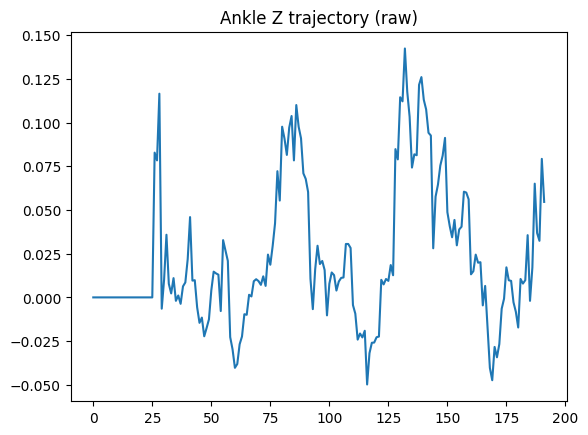

Thigh / Shank ratio: 0.9678428786803932


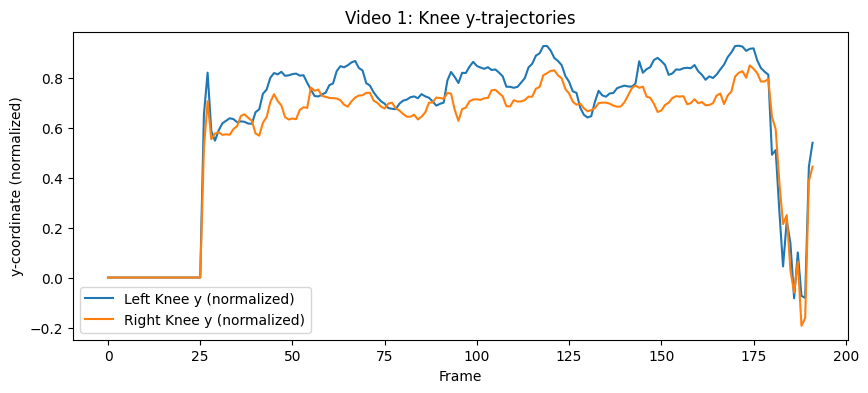

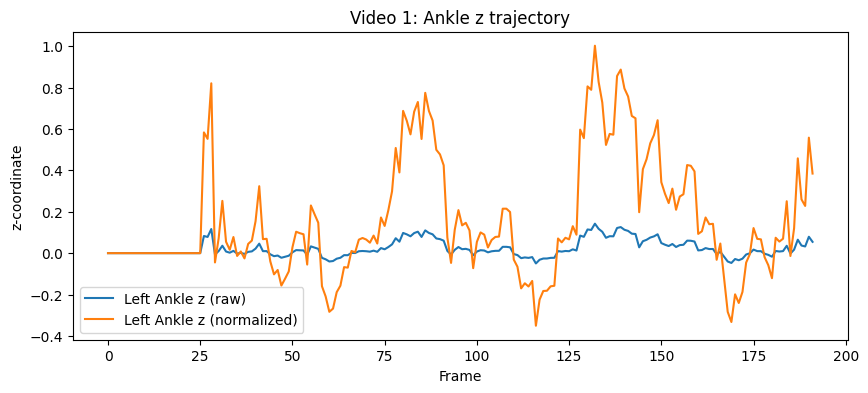

Pose min/max values after normalization:
x: nan nan
y: nan nan
z: nan nan


In [ ]:
#Calling Sanity check function
pose = df_video.iloc[0]['pose']  # full (T,33,3)
sanity_check_pose(pose, title="Video 1")

In [38]:
# QC on clips

import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def qc_gait_clip(clip, fps, visualize=False, title=""):

    GAIT_JOINTS = [
        2, 5,     # eyes
        11, 12,   # shoulders
        23, 24,   # hips
        25, 26,   # knees
        27, 28,   # ankles
        29, 30,   # heels
        31, 32    # foot index
    ]
    # Map to reduced clip indices (0–13)
    LEFT_HIP_IDX = GAIT_JOINTS.index(23)
    RIGHT_HIP_IDX = GAIT_JOINTS.index(24)
    LEFT_SHOULDER_IDX = GAIT_JOINTS.index(11)
    LEFT_KNEE_IDX = GAIT_JOINTS.index(25)
    LEFT_ANKLE_IDX = GAIT_JOINTS.index(27)

    qc = {}

    # Length
    qc["n_frames"] = clip.shape[0]
    qc["duration_s"] = clip.shape[0] / fps
    qc["flag_short"] = qc["n_frames"] < 40

    # Pelvis centering
    pelvis = (clip[:, LEFT_HIP_IDX] + clip[:, RIGHT_HIP_IDX]) / 2
    qc["pelvis_offset"] = np.linalg.norm(pelvis.mean(axis=0))
    qc["flag_off_center"] = qc["pelvis_offset"] > 0.05

    # Torso length
    torso = (clip[:, LEFT_SHOULDER_IDX] - pelvis)
    qc["torso_mean_length"] = np.linalg.norm(torso, axis=1).mean()

    # Smoothness (ankle Y)
    ankle_y = clip[:, LEFT_ANKLE_IDX, 1]
    qc["ankle_y_velocity_std"] = np.std(np.diff(ankle_y))
    qc["flag_jitter"] = qc["ankle_y_velocity_std"] > 0.15

    # Periodicity (knee Y)
    knee_y = clip[:, LEFT_KNEE_IDX, 1]
    peaks, _ = find_peaks(knee_y, distance=int(0.4*fps))
    qc["n_knee_peaks"] = len(peaks)
    qc["flag_no_periodicity"] = qc["n_knee_peaks"] < 1

    # Depth stability (ankle Z)
    ankle_z = clip[:, LEFT_ANKLE_IDX, 2]
    qc["ankle_z_range"] = ankle_z.max() - ankle_z.min()
    qc["ankle_z_spike"] = np.max(np.abs(np.diff(ankle_z)))
    qc["flag_flat_depth"] = qc["ankle_z_range"] < 0.1

    # Overall fail
    qc["qc_fail"] = any([
        qc["flag_short"],
        qc["flag_off_center"],
        qc["flag_jitter"],
        qc["flag_no_periodicity"],
        qc["flag_flat_depth"]
    ])

    # Optional plotting
    if visualize:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.plot(knee_y)
        plt.title(f"{title} - Knee Y")
        plt.subplot(1,2,2)
        plt.plot(ankle_z)
        plt.title(f"{title} - Ankle Z")
        plt.show()

    return qc


In [39]:
qc_rows = []

for i, clip in enumerate(X_clips):
    qc = qc_gait_clip(clip, fps=60, visualize=False, title=f"Clip {i}")
    qc_rows.append(qc)

qc_df = pd.DataFrame(qc_rows)

# Summary
print("Total clips:", len(X_clips))
print("QC fail count:", qc_df["qc_fail"].sum())
print("QC fail %:", 100*qc_df["qc_fail"].mean())

qc_df[[
    'flag_short',
    'flag_off_center',
    'flag_jitter',
    'flag_no_periodicity',
    'flag_flat_depth'
]].sum()

Total clips: 3583
QC fail count: 53
QC fail %: 1.4792073681272677


flag_short              0
flag_off_center         0
flag_jitter            52
flag_no_periodicity     1
flag_flat_depth         0
dtype: int64

array([[<Axes: title={'center': 'n_frames'}>,
        <Axes: title={'center': 'pelvis_offset'}>],
       [<Axes: title={'center': 'ankle_y_velocity_std'}>,
        <Axes: title={'center': 'n_knee_peaks'}>],
       [<Axes: title={'center': 'ankle_z_range'}>, <Axes: >]],
      dtype=object)

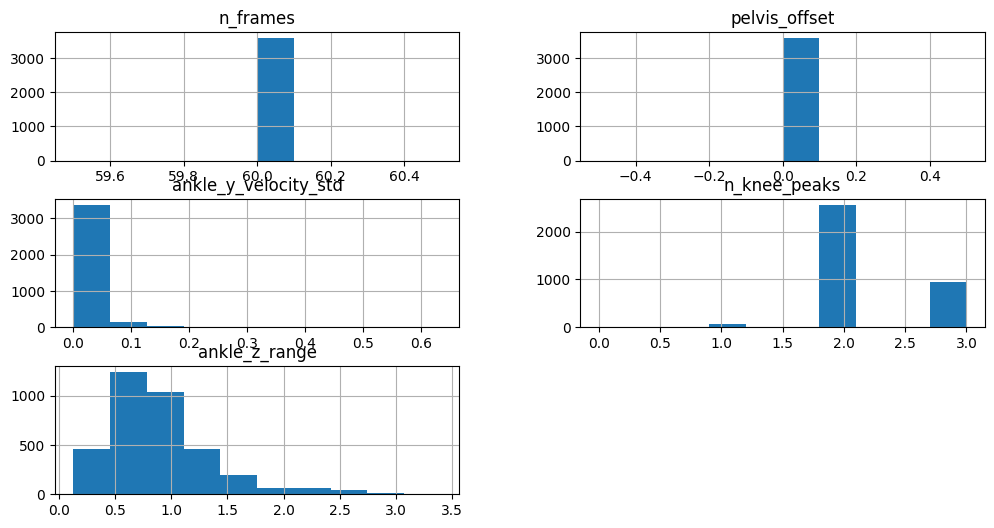

In [40]:

qc_df[['n_frames','pelvis_offset','ankle_y_velocity_std','n_knee_peaks','ankle_z_range']].hist(figsize=(12,6))

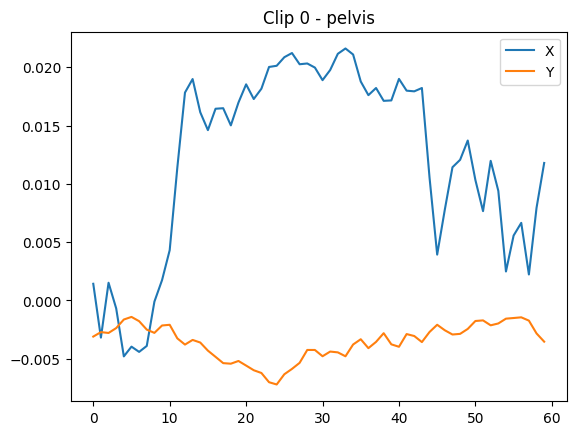

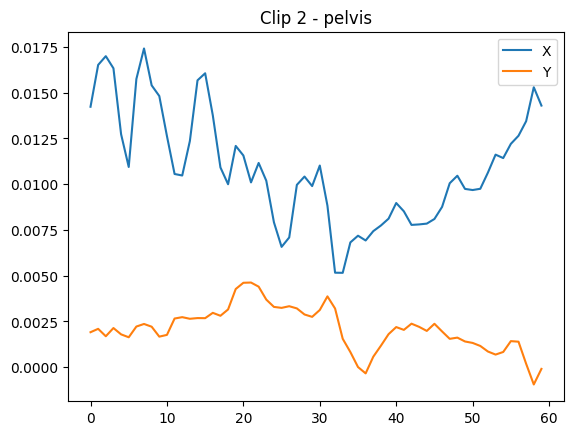

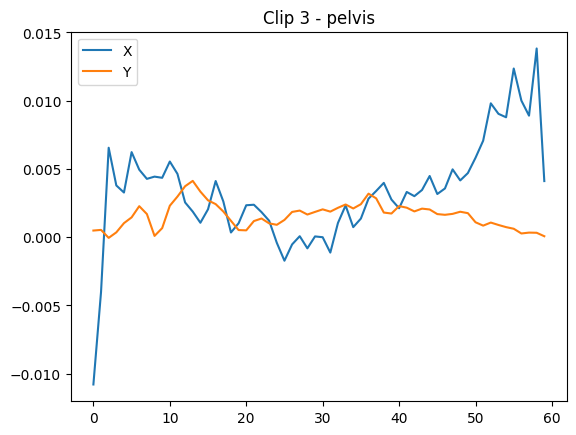

In [ ]:
for i in qc_df[qc_df['flag_off_center']].index[:3]:
    clip = X_clips[i]
    pelvis = clip[:, GAIT_JOINTS.index(23)] + clip[:, GAIT_JOINTS.index(24)]
    pelvis /= 2
    plt.plot(pelvis[:,0], label="X")
    plt.plot(pelvis[:,1], label="Y")
    plt.title(f"Clip {i} - pelvis")
    plt.legend()
    plt.show()


In [41]:
for i in qc_df[qc_df['flag_flat_depth']].index[:3]:
    clip = X_clips[i]
    ankle_z = clip[:, GAIT_JOINTS.index(27), 2]
    plt.plot(ankle_z)
    plt.title(f"Clip {i} - ankle Z")
    plt.show()


**Heel Strike QC**

In [42]:
#QC Function - Heel Strike
def plot_gait_cycle_qc(pose, fps=30, smooth_sigma=1, min_time_between_steps=0.5,
                       resample_frames=60, GAIT_JOINTS=None):
    """
    Plot left/right heel trajectories with detected strikes and extracted clips.
    
    Args:
        pose: (T, 33, 3) full pose sequence
        fps: frames per second
        smooth_sigma: smoothing for heel trajectories
        min_time_between_steps: min seconds between consecutive heel strikes
        resample_frames: number of frames used in extracted clips
        GAIT_JOINTS: optional list of joint indices used for ML
    """
    LEFT_HEEL, RIGHT_HEEL = 29, 30
    frames = np.arange(pose.shape[0])
    
    # Extract heel y-coordinates
    left_y = gaussian_filter1d(pose[:, LEFT_HEEL, 1], sigma=smooth_sigma)
    right_y = gaussian_filter1d(pose[:, RIGHT_HEEL, 1], sigma=smooth_sigma)
    
    # Detect heel strikes
    left_strikes = find_heel_strikes(pose, 'left', fps=fps,
                                     min_time_between_steps=min_time_between_steps,
                                     smooth_sigma=smooth_sigma)
    right_strikes = find_heel_strikes(pose, 'right', fps=fps,
                                      min_time_between_steps=min_time_between_steps,
                                      smooth_sigma=smooth_sigma)
    
    # Extract clips using your function
    clips = extract_gait_cycle_clips(pose, fps=fps, cycles=1,
                                     min_time_between_steps=min_time_between_steps,
                                     resample_frames=resample_frames)
    
    # Determine start/end frames of clips
    clip_ranges = []
    for clip in clips:
        start_idx = np.where((pose[:, :3] == clip[0, :3]).all(axis=(1,2)))[0]
        end_idx = start_idx + clip.shape[0] if len(start_idx) > 0 else [None]
        if len(start_idx) > 0:
            clip_ranges.append((start_idx[0], start_idx[0]+clip.shape[0]-1))
    
    # Plot
    plt.figure(figsize=(14,5))
    plt.plot(frames, left_y, label='Left Heel', color='blue')
    plt.plot(frames, right_y, label='Right Heel', color='red')
    plt.scatter(left_strikes, left_y[left_strikes], color='cyan', label='Left Heel Strike', zorder=5)
    plt.scatter(right_strikes, right_y[right_strikes], color='magenta', label='Right Heel Strike', zorder=5)
    
    # Mark start/end of each clip
    for start, end in clip_ranges:
        plt.axvline(start, color='green', linestyle='--', alpha=0.6)
        plt.axvline(end, color='orange', linestyle='--', alpha=0.6)
    
    plt.xlabel("Frame")
    plt.ylabel("Heel Y-coordinate")
    plt.title("QC: Heel Trajectories, Heel Strikes, Clip Start/End")
    plt.legend()
    plt.grid(True)
    plt.show()


In [45]:
pose_norm = df_video.loc[0, "pose"]  # raw normalized pose for first trial
plot_gait_cycle_qc(pose_norm, fps=30)


AttributeError: 'DataFrame' object has no attribute 'loc'

In [47]:
# Assume pose_norm is your processed pose sequence
plot_gait_cycle_qc(pose, fps=30, smooth_sigma=1, min_time_between_steps=0.5)


NameError: name 'pose' is not defined

In [48]:
# Loop over first 3 rows by position
for idx in range(3):
    pose_norm = df_video.iloc[idx]["pose"]  # use iloc for positions
    print(f"QC for row {idx}")
    plot_gait_cycle_qc(pose_norm, fps=30)


AttributeError: 'DataFrame' object has no attribute 'iloc'

In [ ]:
def extract_gait_cycle_clips(pose, fps, cycles=1, min_time_between_steps=0.5,
                             min_frames=40, max_frames=150, resample_frames=60):
    """
    Returns:
        clips: list of arrays (resample_frames, 33, 3)
        clip_ranges: list of tuples (start_frame, end_frame) in original pose
    """
    clips = []
    clip_ranges = []

    left_events = find_heel_strikes(pose, "left", fps, min_time_between_steps)
    right_events = find_heel_strikes(pose, "right", fps, min_time_between_steps)

    for foot_events in [left_events, right_events]:
        for i in range(len(foot_events) - cycles):
            s = foot_events[i]
            e = foot_events[i + cycles]
            clip = pose[s:e]

            if min_frames <= len(clip) <= max_frames:
                clip_resampled = resample(clip, resample_frames, axis=0)
                clips.append(clip_resampled)
                clip_ranges.append((s, e-1))  # store start and end frames

    return clips, clip_ranges


In [ ]:
# Extract clips and ranges
X_clips, clip_ranges = extract_gait_cycle_clips(pose_norm, fps=30, cycles=1, resample_frames=60)

# Print start/end frames of each clip
for i, (start, end) in enumerate(clip_ranges):
    print(f"Clip {i}: start={start}, end={end}")


Clip 0: start=66, end=113
Clip 1: start=39, end=88


In [ ]:
def plot_gait_cycle_qc(pose, clip_ranges, fps=30):
    LEFT_HEEL, RIGHT_HEEL = 29, 30
    frames = np.arange(pose.shape[0])  # full pose frame indices
    left_y = pose[:, LEFT_HEEL, 1]
    right_y = pose[:, RIGHT_HEEL, 1]

    # Detect heel strikes
    left_strikes = find_heel_strikes(pose, "left", fps=fps)
    right_strikes = find_heel_strikes(pose, "right", fps=fps)

    plt.figure(figsize=(14,5))
    plt.plot(frames, left_y, label="Left Heel", color="blue")
    plt.plot(frames, right_y, label="Right Heel", color="red")
    plt.scatter(left_strikes, left_y[left_strikes], color="cyan", label="Left Heel Strike")
    plt.scatter(right_strikes, right_y[right_strikes], color="magenta", label="Right Heel Strike")

    # Clip boundaries (use full pose indices!)
    for start, end in clip_ranges:
        plt.axvline(start, color="green", linestyle="--", alpha=0.6, label="Clip Start")
        plt.axvline(end, color="orange", linestyle="--", alpha=0.6, label="Clip End")

    plt.xlabel("Frame")
    plt.ylabel("Heel Y-coordinate")
    plt.title("QC: Heel Trajectories + Clips")
    plt.legend()
    plt.grid(True)
    plt.show()


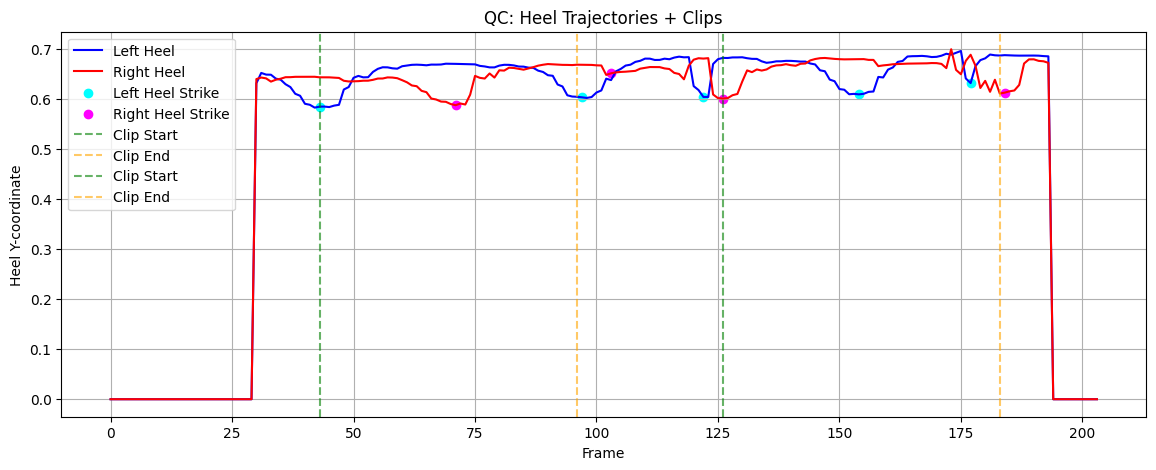

In [ ]:
pose_norm = df_video.iloc[6]["pose"]
X_clips, clip_ranges = extract_gait_cycle_clips(pose_norm, fps=30, cycles=1, resample_frames=60)
plot_gait_cycle_qc(pose_norm, clip_ranges, fps=30)


In [ ]:
X_clips, clip_ranges = extract_gait_cycle_clips(pose_norm, fps=30, cycles=1, resample_frames=60)
print(clip_ranges)


[]


In [ ]:
left_events = find_heel_strikes(pose_norm, "left", fps=30, min_time_between_steps=0.4)
print("Left strikes:", left_events)


Left strikes: [ 33  47  69  83 101 129 143 156]


In [ ]:
left_events = find_heel_strikes(pose_norm, 'left', fps=30)
right_events = find_heel_strikes(pose_norm, 'right', fps=30)
print("Left strikes:", left_events)
print("Right strikes:", right_events)


Left strikes: [ 30  65  80  95 119 144 171 188]
Right strikes: [ 40  72  91 107 124 147 175]


In [ ]:
def extract_gait_cycle_clips_debug(pose, fps, cycles=1, min_time_between_steps=0.5,
                                   min_frames=40, max_frames=150, resample_frames=60):
    clips = []
    clip_ranges = []

    left_events = find_heel_strikes(pose, "left", fps, min_time_between_steps)
    right_events = find_heel_strikes(pose, "right", fps, min_time_between_steps)
    print("Left events:", left_events)
    print("Right events:", right_events)

    for foot_events in [left_events, right_events]:
        for i in range(len(foot_events) - cycles):
            s = foot_events[i]
            e = foot_events[i + cycles]
            print("Candidate clip:", s, e, "length:", e-s)
            clip = pose[s:e]
            if min_frames <= len(clip) <= max_frames:
                clip_resampled = resample(clip, resample_frames, axis=0)
                clips.append(clip_resampled)
                clip_ranges.append((s, e-1))
                print("Clip added:", s, e-1)
            else:
                print("Clip rejected:", s, e-1, "length out of bounds")

    return clips, clip_ranges



In [ ]:
print(clips)

NameError: name 'clips' is not defined

In [ ]:
# READY for both approaches

#Feature-based ML (XGBoost / RF)
# Example reshape for feature extraction
clip = X_clips[0]  # (60, 33, 3)

# Deep Learning
X_dl = X_clips.reshape(len(X_clips), 60, -1)


We utilized the 3D output of MediaPipe Pose (x, y, z), where the z-dimension represents relative depth. All joints were pelvis-centered and scaled by torso length to ensure comparability across subjects.

In [ ]:
                ┌───────────────┐
30fps healthy → │ Pose sequence │
60fps pathology │  (T, J, 3)    │
                └──────┬────────┘
                       │
                       ▼
           ┌─────────────────────────┐
           │  Normalize Pose 3D      │
           │  - Pelvis-centered      │
           │  - Scaled by torso      │
           │  - Works for x, y, z   │
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ Detect Heel Strikes      │
           │  - Use FPS from metadata │
           │  - Convert min_time → frames
           │  - Separate left/right │
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ Extract Gait-Cycle Clips│
           │  - Each clip = 1–2 cycles│
           │  - Clips may vary in length│
           │  - Filter min/max frames │
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ Resample Clips           │
           │  - Fixed number of frames│
           │  - Example: 60 frames   │
           │  - Works for 30fps & 60fps│
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ Optional: Feature Calc  │
           │  - x, y, z coordinates  │
           │  - Velocity, acceleration│
           │  - Normalize by dt=1/fps│
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ ML Model Input           │
           │  - Shape: (resample_frames, J*3) │
           │  - LSTM / Transformer / CNN │
           └─────────────────────────┘
